# <center><div style="font-family: Trebuchet MS; background-color: #F93822; color: #FDD20E; padding: 12px; line-height: 1;">Import libraries</div></center>



In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
pd.options.display.float_format = '{:.2f}'.format
import warnings
warnings.filterwarnings('ignore')

In [106]:
data = pd.read_csv('../input/heart-failure-prediction/heart.csv')
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.00,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.00,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.00,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.50,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.00,Up,0


### Data Info :

In [107]:
data.shape

(918, 12)

In [108]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [109]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


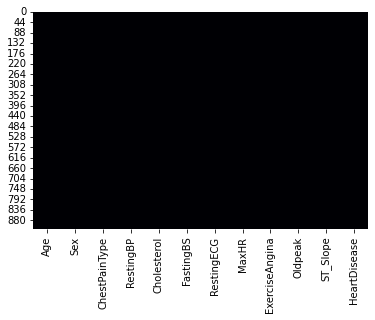

In [110]:
sns.heatmap(data.isnull(),cmap = 'magma',cbar = False);

- **No null values** present in the data!

In [111]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.00,53.51,9.43,28.00,47.00,54.00,60.00,77.00
RestingBP,918.00,132.40,18.51,0.00,120.00,130.00,140.00,200.00
Cholesterol,918.00,198.80,109.38,0.00,173.25,223.00,267.00,603.00
FastingBS,918.00,0.23,0.42,0.00,0.00,0.00,0.00,1.00
MaxHR,918.00,136.81,25.46,60.00,120.00,138.00,156.00,202.00
Oldpeak,918.00,0.89,1.07,-2.60,0.00,0.60,1.50,6.20
HeartDisease,918.00,0.55,0.50,0.00,0.00,1.00,1.00,1.00


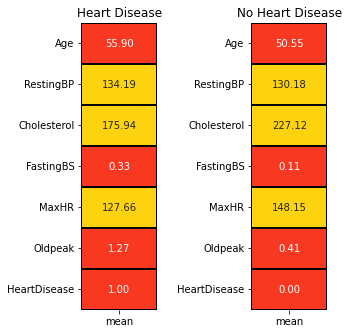

In [112]:
yes = data[data['HeartDisease'] == 1].describe().T
no = data[data['HeartDisease'] == 0].describe().T
colors = ['#F93822','#FDD20E']

fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (5,5))
plt.subplot(1,2,1)
sns.heatmap(yes[['mean']],annot = True,cmap = colors,linewidths = 0.4,linecolor = 'black',cbar = False,fmt = '.2f',)
plt.title('Heart Disease');

plt.subplot(1,2,2)
sns.heatmap(no[['mean']],annot = True,cmap = colors,linewidths = 0.4,linecolor = 'black',cbar = False,fmt = '.2f')
plt.title('No Heart Disease');

fig.tight_layout(pad = 2)

- **Mean** values of all the features for cases of heart diseases and non-heart diseases.

# <center><div style="font-family: Trebuchet MS; background-color: #F93822; color: #FDD20E; padding: 12px; line-height: 1;">Exploratory Data Analysis</div></center>

### Dividing features into Numerical and Categorical :

In [113]:
col = list(data.columns)
categorical_features = []
numerical_features = []
for i in col:
    if len(data[i].unique()) > 6:
        numerical_features.append(i)
    else:
        categorical_features.append(i)

print('Categorical Features :',*categorical_features)
print('Numerical Features :',*numerical_features)

Categorical Features : Sex ChestPainType FastingBS RestingECG ExerciseAngina ST_Slope HeartDisease
Numerical Features : Age RestingBP Cholesterol MaxHR Oldpeak


- Here, categorical features are defined if the the attribute has less than 6 unique elements else it is a numerical feature.
- Typical approach for this division of features can also be based on the datatypes of the elements of the respective attribute.

**Eg :** datatype = integer, attribute = numerical feature ; datatype = string, attribute = categorical feature

- For this dataset, as the number of features are less, we can manually check the dataset as well.

### Categorical Features :

In [114]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1 = data.copy(deep = True)

df1['Sex'] = le.fit_transform(df1['Sex'])
df1['ChestPainType'] = le.fit_transform(df1['ChestPainType'])
df1['RestingECG'] = le.fit_transform(df1['RestingECG'])
df1['ExerciseAngina'] = le.fit_transform(df1['ExerciseAngina'])
df1['ST_Slope'] = le.fit_transform(df1['ST_Slope'])

- Creating a deep copy of the orginal dataset and label encoding the text data of the categorical features.
- Modifications in the original dataset will not be highlighted in this deep copy.
- Hence, we use this deep copy of dataset that has all the features converted into numerical values for visualization & modeling purposes.

#### Distribution of Categorical Features :

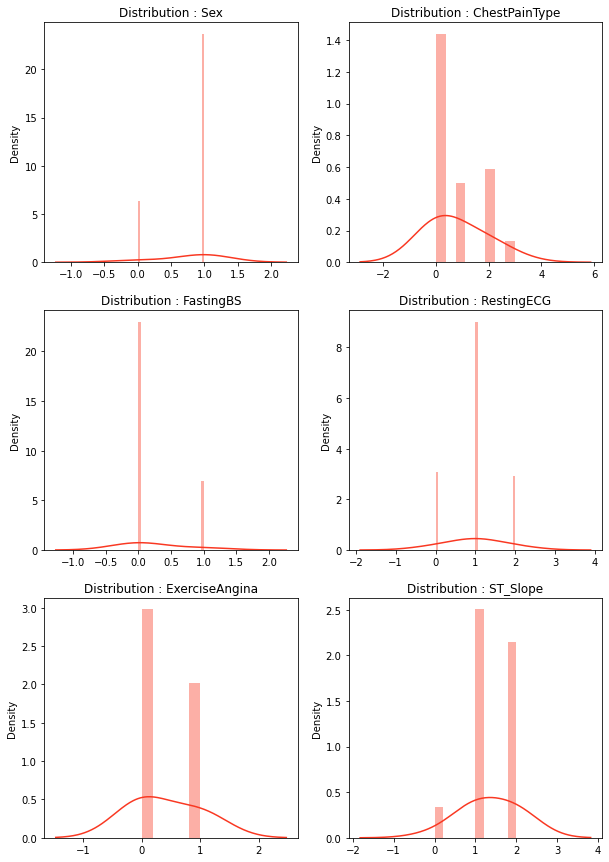

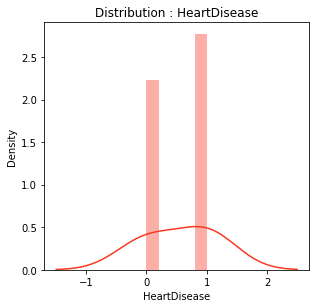

In [115]:
fig, ax = plt.subplots(nrows = 3,ncols = 2,figsize = (10,15))
for i in range(len(categorical_features) - 1):
    
    plt.subplot(3,2,i+1)
    sns.distplot(x=df1[categorical_features[i]],kde_kws = {'bw' : 1},color = colors[0]);
    title = 'Distribution : ' + categorical_features[i]
    plt.title(title)
    
plt.figure(figsize = (4.75,4.55))
sns.distplot(df1[categorical_features[len(categorical_features) - 1]],kde_kws = {'bw' : 1},color = colors[0])
title = 'Distribution : ' + categorical_features[len(categorical_features) - 1]
plt.title(title);

- All the categorical features are near about **Normally Distributed**.

### Numerical Features :

#### Distribution of Numerical Features :

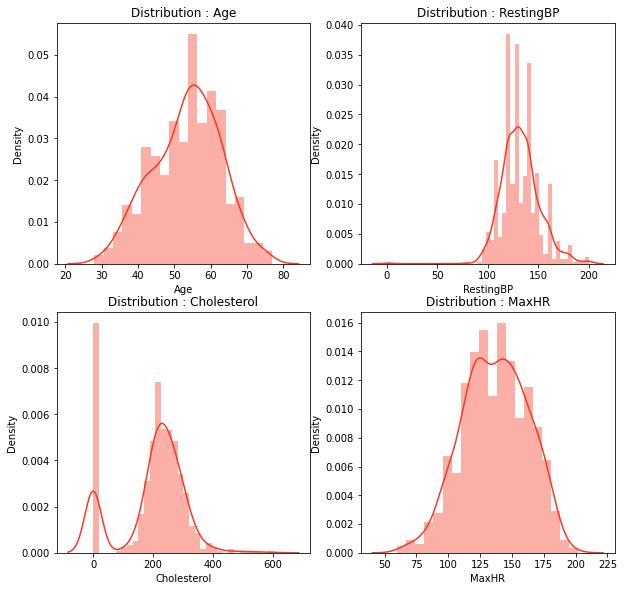

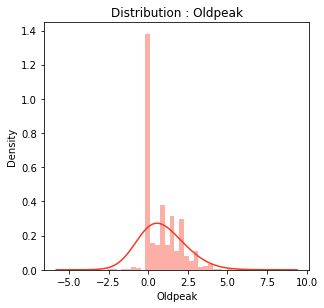

In [116]:
fig, ax = plt.subplots(nrows = 2,ncols = 2,figsize = (10,9.75))
for i in range(len(numerical_features) - 1):
    plt.subplot(2,2,i+1)
    sns.distplot(data[numerical_features[i]],color = colors[0])
    title = 'Distribution : ' + numerical_features[i]
    plt.title(title)
plt.show()

plt.figure(figsize = (4.75,4.55))
sns.distplot(df1[numerical_features[len(numerical_features) - 1]],kde_kws = {'bw' : 1},color = colors[0])
title = 'Distribution : ' + numerical_features[len(numerical_features) - 1]
plt.title(title);

- **Oldpeak's** data distribution is rightly skewed.
- **Cholestrol** has a bidmodal data distribution. 

### Target Variable Visualization (HeartDisease) : 

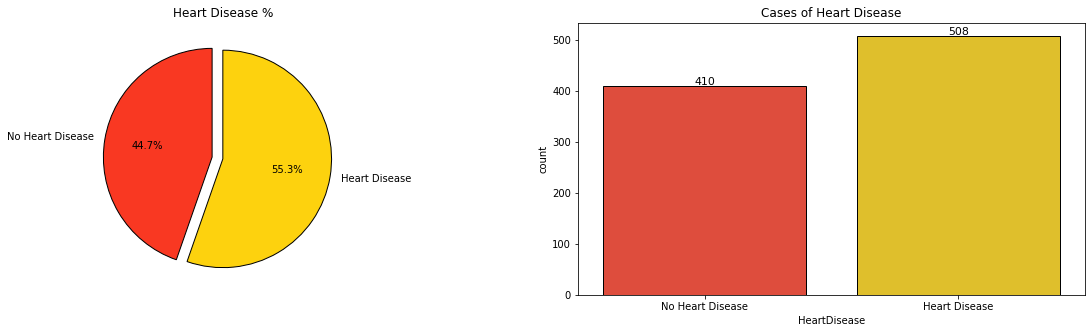

In [117]:
l = list(data['HeartDisease'].value_counts())
circle = [l[1] / sum(l) * 100,l[0] / sum(l) * 100]

fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (20,5))
plt.subplot(1,2,1)
plt.pie(circle,labels = ['No Heart Disease','Heart Disease'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
        wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Heart Disease %');

plt.subplot(1,2,2)
ax = sns.countplot('HeartDisease',data = data,palette = colors,edgecolor = 'black')
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 2, rect.get_height(), horizontalalignment='center', fontsize = 11)
ax.set_xticklabels(['No Heart Disease','Heart Disease'])
plt.title('Cases of Heart Disease');
plt.show()

- The dataset is pretty much **evenly balanced!**

### Categorical Features vs Target Variable (HeartDisease) :

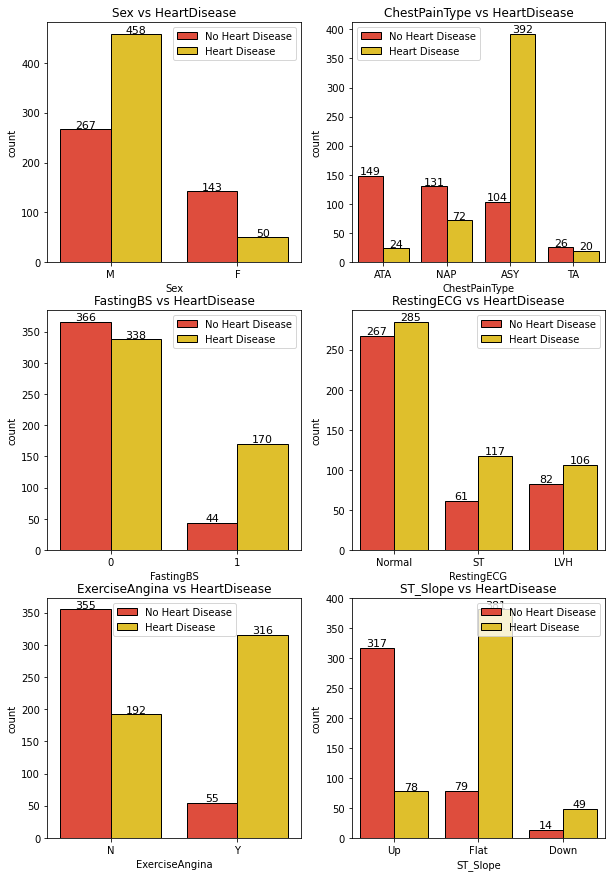

In [118]:
fig, ax = plt.subplots(nrows = 3,ncols = 2,figsize = (10,15))
for i in range(len(categorical_features) - 1):
    plt.subplot(3,2,i+1)
    ax = sns.countplot(x=categorical_features[i],data = data,hue = "HeartDisease",palette = colors,edgecolor = 'black')
    for rect in ax.patches:
        ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 2, rect.get_height(), horizontalalignment='center', fontsize = 11)
    title = categorical_features[i] + ' vs HeartDisease'
    plt.legend(['No Heart Disease','Heart Disease'])
    plt.title(title);

- **Male** population has more heart disease patients than no heart disease patients. In the case of **Female** population, heart disease patients are less than no heart disease patients. 
- **ASY** type of chest pain boldly points towards major chances of heart disease.
- **Fasting Blood Sugar** is tricky! Patients diagnosed with Fasting Blood Sugar and no Fasting Blood Sugar have significant heart disease patients. 
- **RestingECG** does not present with a clear cut category that highlights heart disease patients. All the 3 values consist of high number of heart disease patients.
- **Exercise Induced Engina** definitely bumps the probability of being diagnosed with heart diseases.
- With the **ST_Slope** values, **flat** slope displays a very high probability of being diagnosed with heart disease. **Down** also shows the same output but in very few data points. 

### Categorical Features vs Positive Heart Disease Cases :

In [119]:
sex = data[data['HeartDisease'] == 1]['Sex'].value_counts()
sex = [sex[0] / sum(sex) * 100, sex[1] / sum(sex) * 100]

cp = data[data['HeartDisease'] == 1]['ChestPainType'].value_counts()
cp = [cp[0] / sum(cp) * 100,cp[1] / sum(cp) * 100,cp[2] / sum(cp) * 100,cp[3] / sum(cp) * 100]

fbs = data[data['HeartDisease'] == 1]['FastingBS'].value_counts()
fbs = [fbs[0] / sum(fbs) * 100,fbs[1] / sum(fbs) * 100]

restecg = data[data['HeartDisease'] == 1]['RestingECG'].value_counts()
restecg = [restecg[0] / sum(restecg) * 100,restecg[1] / sum(restecg) * 100,restecg[2] / sum(restecg) * 100]

exang = data[data['HeartDisease'] == 1]['ExerciseAngina'].value_counts()
exang = [exang[0] / sum(exang) * 100,exang[1] / sum(exang) * 100]

slope = data[data['HeartDisease'] == 1]['ST_Slope'].value_counts()
slope = [slope[0] / sum(slope) * 100,slope[1] / sum(slope) * 100,slope[2] / sum(slope) * 100]

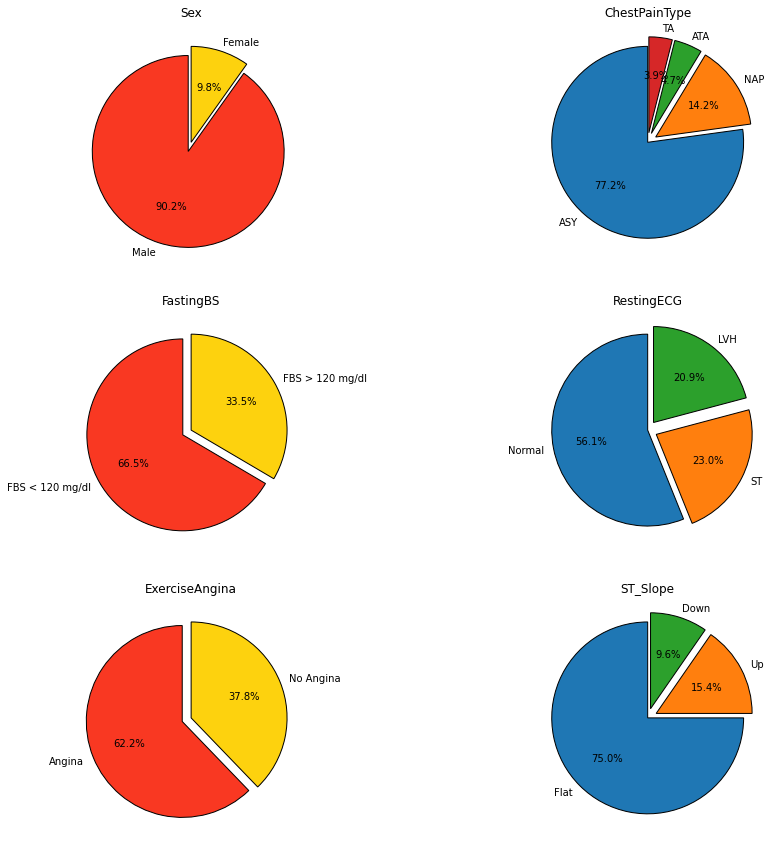

In [120]:
ax,fig = plt.subplots(nrows = 4,ncols = 2,figsize = (15,15))

plt.subplot(3,2,1)
plt.pie(sex,labels = ['Male','Female'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
        wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Sex');

plt.subplot(3,2,2)
plt.pie(cp,labels = ['ASY', 'NAP', 'ATA', 'TA'],autopct='%1.1f%%',startangle = 90,explode = (0,0.1,0.1,0.1),
        wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('ChestPainType');

plt.subplot(3,2,3)
plt.pie(fbs,labels = ['FBS < 120 mg/dl','FBS > 120 mg/dl'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
        wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('FastingBS');

plt.subplot(3,2,4)
plt.pie(restecg,labels = ['Normal','ST','LVH'],autopct='%1.1f%%',startangle = 90,explode = (0,0.1,0.1),
        wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('RestingECG');

plt.subplot(3,2,5)
plt.pie(exang,labels = ['Angina','No Angina'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
        wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('ExerciseAngina');

plt.subplot(3,2,6)
plt.pie(slope,labels = ['Flat','Up','Down'],autopct='%1.1f%%',startangle = 90,explode = (0,0.1,0.1),
        wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('ST_Slope');

- Out of all the heart disease patients, a staggering 90% patients are **male**.
- When it comes to the type of chest pain, **ASY** type holds the majority with 77% that lead to heart diseases.
- **Fasting Blood Sugar** level < 120 mg/dl displays high chances of heart diseases.
- For **RestingECG**, **Normal** level accounts for 56% chances of heart diseases than **LVH** and **ST** levels.
- Detection of **Exercise Induced Angina** also points towards heart diseases.
- When it comes to **ST_Slope** readings, **Flat** level holds a massive chunk with 75% that may assist in detecting underlying heart problems. 

### Numerical Features vs Target Variable (HeartDisease) :

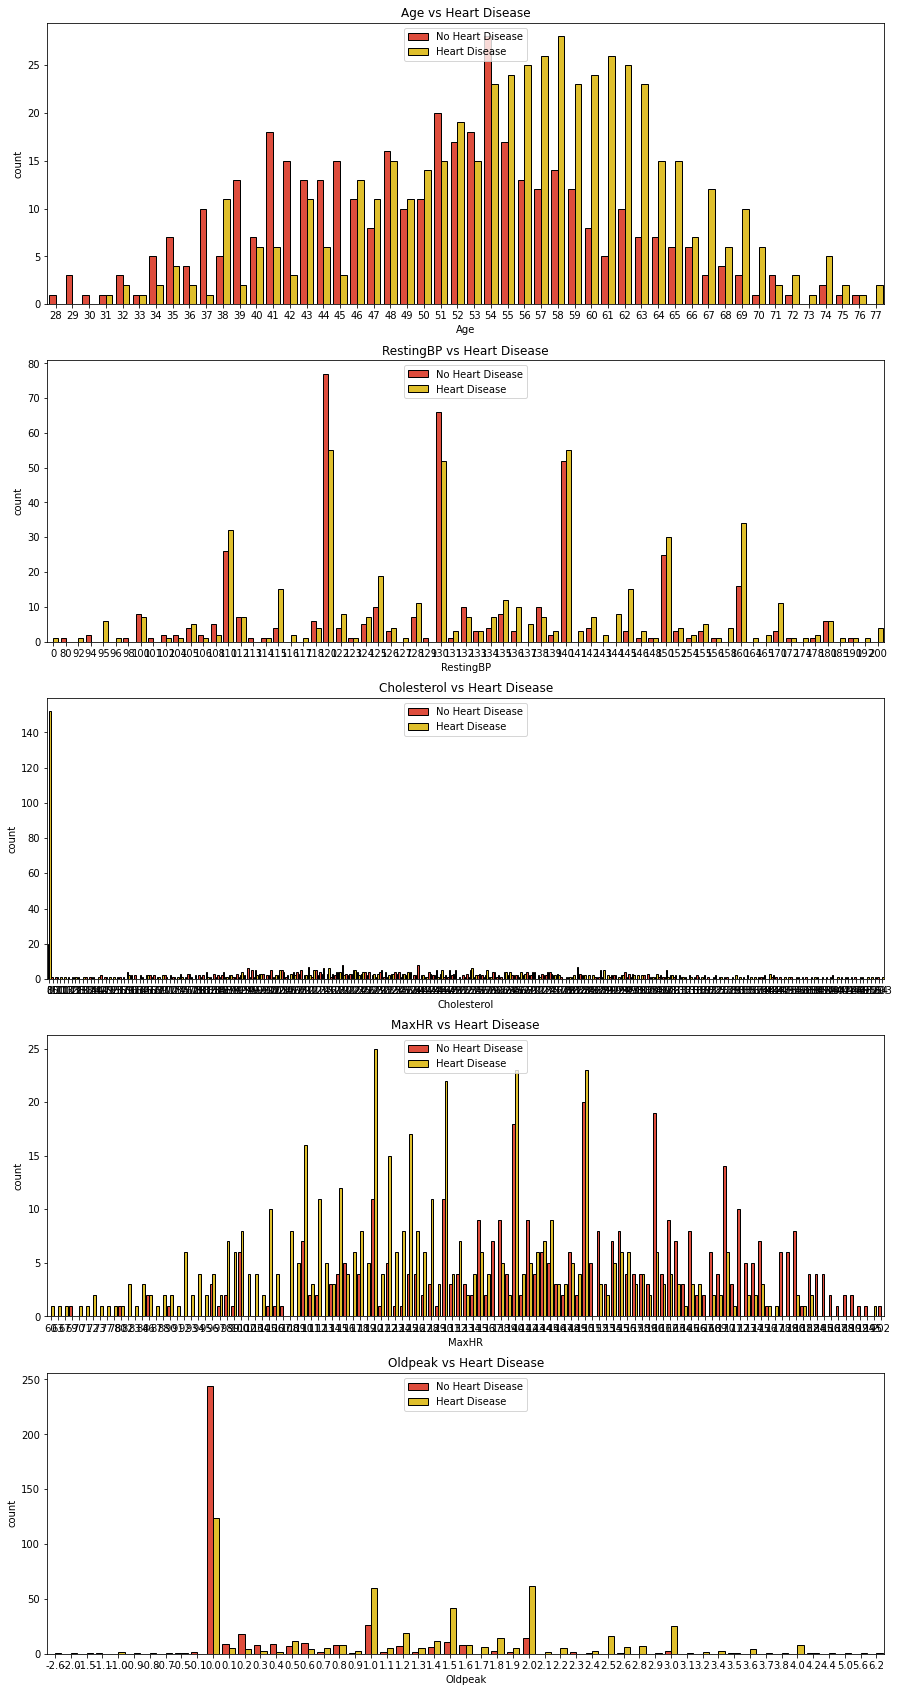

In [121]:
fig, ax = plt.subplots(nrows = 5,ncols = 1,figsize = (15,30))
for i in range(len(numerical_features)):
    plt.subplot(5,1,i+1)
    sns.countplot(x=numerical_features[i],data = data,hue = "HeartDisease",palette = colors, edgecolor = 'black')
    title = numerical_features[i] + ' vs Heart Disease'
    plt.legend(['No Heart Disease','Heart Disease'])
    plt.title(title);

- Because of too many unique data points in the above features, it is difficult to gain any type of insight. Thus, we will convert these numerical features,except age, into categorical features for understandable visualization and gaining insights purposes. 
- Thus, we scale the individual values of these features. This brings the varied data points to a constant value that represents a range of values.
- Here, we divide the data points of the numerical features by 5 or 10 and assign its quotient value as the representative constant for that data point. The scaling constants of 5 & 10 are decided by looking into the data & intuition. 

In [122]:
data['RestingBP_Group'] = [ int(i / 5) for i in data['RestingBP']]
data['Cholesterol_Group'] = [ int(i / 10) for i in data['Cholesterol']]
data['MaxHR_Group'] = [ int(i / 5) for i in data['MaxHR']]
data['Oldpeak_Group'] = [ int( (i*10) / 5) for i in data['Oldpeak']]

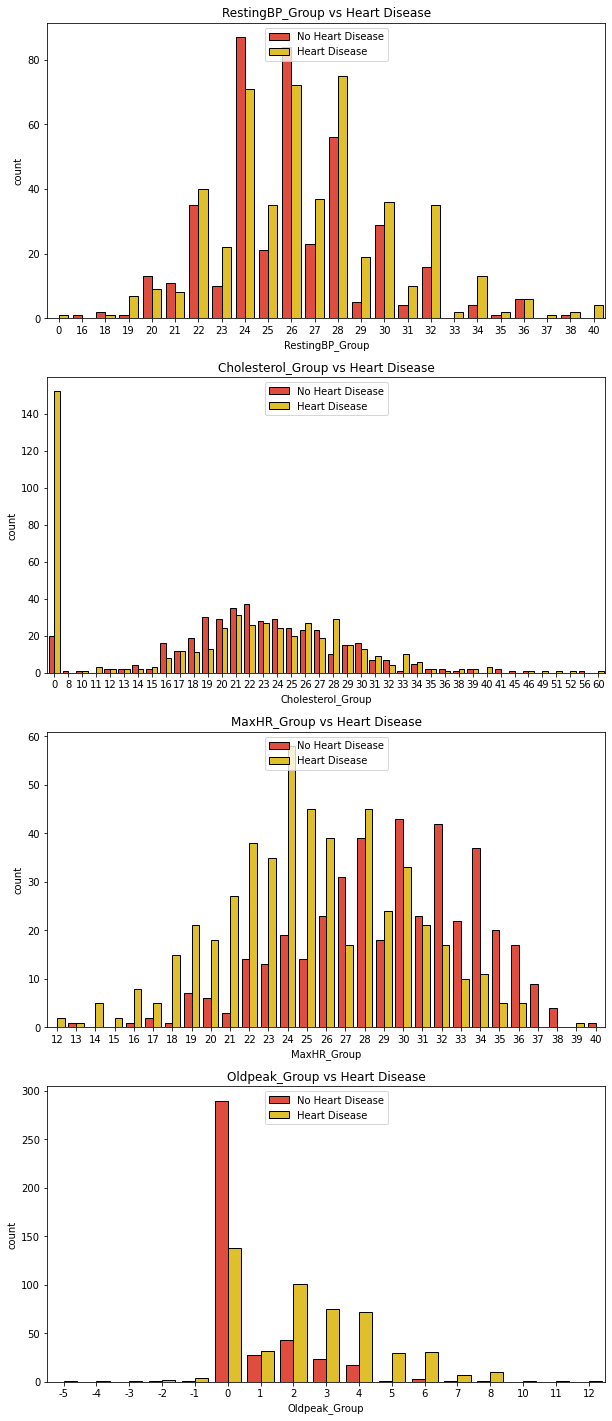

In [123]:
fig, ax = plt.subplots(nrows = 4,ncols = 1,figsize = (10,25))
group_numerical_features = [i + '_Group' for i in numerical_features[1:]]
for i in range(len(group_numerical_features)):
    plt.subplot(4,1,i+1)
    sns.countplot(x=group_numerical_features[i],data = data,hue = "HeartDisease",palette = colors, edgecolor = 'black')
    plt.legend(['No Heart Disease', 'Heart Disease'])
    title = group_numerical_features[i] + ' vs Heart Disease'
    plt.title(title);

- From the **RestingBP** group data, **95** (19x5) - **170** (34x5) readings are most prone to be detected with heart diseases.
- **Cholesterol** levels between **160** (16x10) - **340** (34x10) are highly susceptible to heart diseases.
- For the **MaxHR** readings, heart diseases are found throughout the data but **70** (14x5) - **180** (36x5) values has detected many cases. 
- **Oldpeak** values also display heart diseases throughout. **0** (0x5/10) - **4** (8x5/10) slope values display high probability to be diagnosed with heart diseases.

### Numerical features vs Categorical features w.r.t Target variable(HeartDisease) :

#### Sex vs Numerical Features :

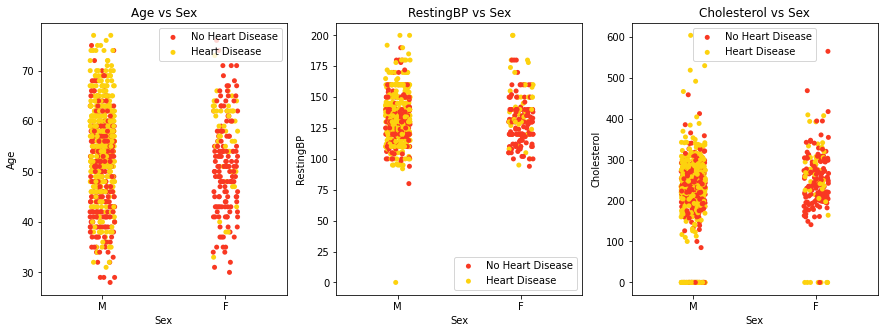

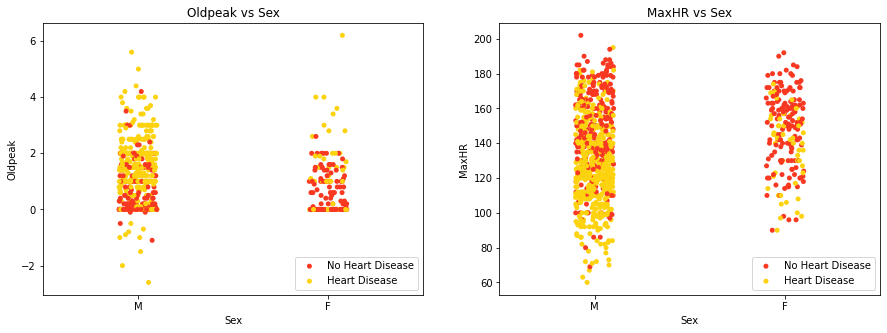

In [124]:
fig,ax = plt.subplots(nrows = 1,ncols = 3,figsize = (15,5))
for i in range(3):
    plt.subplot(1,3,i+1)
    sns.stripplot(x = 'Sex',y = numerical_features[i],data = data,hue = 'HeartDisease',palette = colors);
    plt.legend(['No Heart Disease', 'Heart Disease'])
    title = numerical_features[i] + ' vs Sex' 
    plt.title(title);

fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (15,5))
for i in [-1,-2]:
    plt.subplot(1,2,-i)
    sns.stripplot(x = 'Sex',y = numerical_features[i],data = data,hue = 'HeartDisease',palette = colors);
    plt.legend(['No Heart Disease', 'Heart Disease'])
    title = numerical_features[i] + ' vs Sex' 
    plt.title(title);

- **Male** population displays heart diseases at near about all the values of the numerical features. Above the age of 50, positive old peak values and maximum heart rate below 140, heart diseases in male population become dense.
- **Female** population data points are very less as compared to **male** population data points. Hence, we cannot point to specific ranges or values that display cases of heart diseases. 

#### ChestPainType vs Numerical Features :

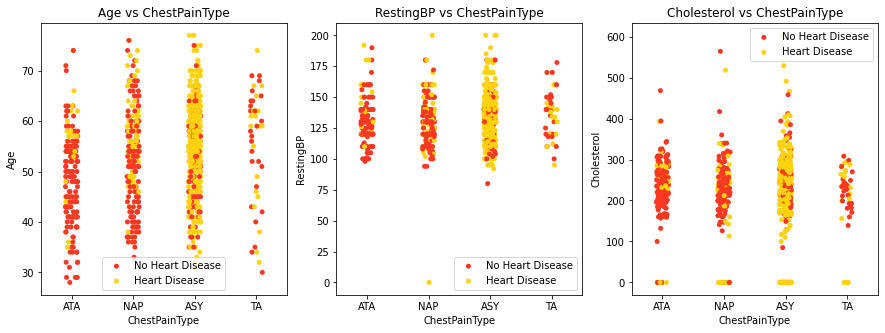

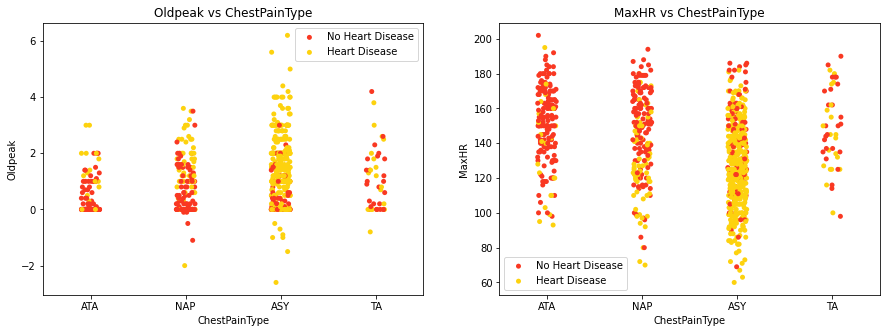

In [125]:
fig,ax = plt.subplots(nrows = 1,ncols = 3,figsize = (15,5))
for i in range(3):
    plt.subplot(1,3,i+1)
    sns.stripplot(x = 'ChestPainType',y = numerical_features[i],data = data,hue = 'HeartDisease',palette = colors);
    plt.legend(['No Heart Disease', 'Heart Disease'])
    title = numerical_features[i] + ' vs ChestPainType'
    plt.title(title);

fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (15,5))
for i in [-1,-2]:
    plt.subplot(1,2,-i)
    sns.stripplot(x = 'ChestPainType',y = numerical_features[i],data = data,hue = 'HeartDisease',palette = colors);
    plt.legend(['No Heart Disease', 'Heart Disease'])
    title = numerical_features[i] + ' vs ChestPainType' 
    plt.title(title);

- **ASY** type of chest pain dominates other types of chest pain in all the numerical features by a lot.

#### FastingBS vs Numerical features :

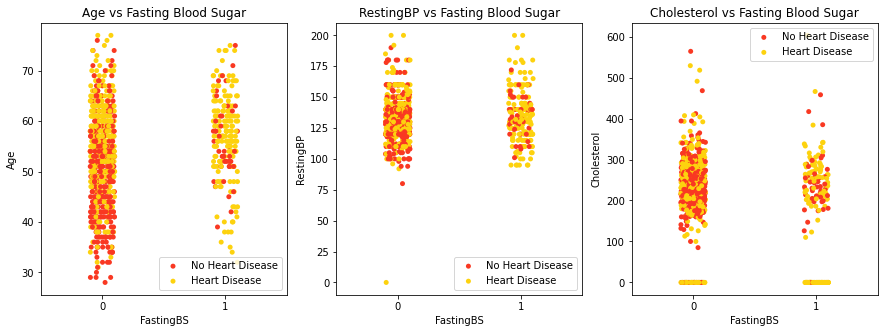

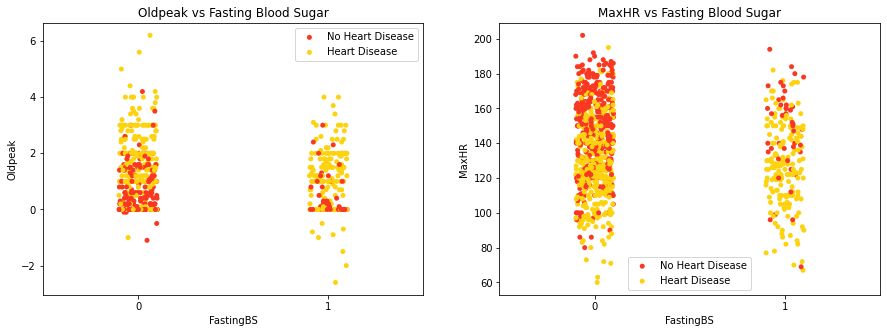

In [126]:
fig,ax = plt.subplots(nrows = 1,ncols = 3,figsize = (15,5))
for i in range(3):
    plt.subplot(1,3,i+1)
    sns.stripplot(x = 'FastingBS',y = numerical_features[i],data = data,hue = 'HeartDisease',palette = colors);
    plt.legend(['No Heart Disease', 'Heart Disease'])
    title = numerical_features[i] + ' vs Fasting Blood Sugar' 
    plt.title(title);

fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (15,5))
for i in [-1,-2]:
    plt.subplot(1,2,-i)
    sns.stripplot(x = 'FastingBS',y = numerical_features[i],data = data,hue = 'HeartDisease',palette = colors);
    plt.legend(['No Heart Disease', 'Heart Disease'])
    title = numerical_features[i] + ' vs Fasting Blood Sugar' 
    plt.title(title);

- Above the **age** 50, heart diseases are found throughout the data irrespective of the patient being diagnosed with Fasting Blood Sugar or not.
- **Fasting Blood Sugar** with **Resting BP** over 100 has displayed more cases of heart diseases than patients with no fasting blood sugar.
- **Cholesterol** with **Fasting Blood Sugar** does not seem to have an effect in understanding reason behind heart diseases.
- Patients that have not been found positive with **Fasting Blood Sugar** but have maximum heart rate below 130 are more prone to heart diseases.

#### RestingECG vs Numerical Features :

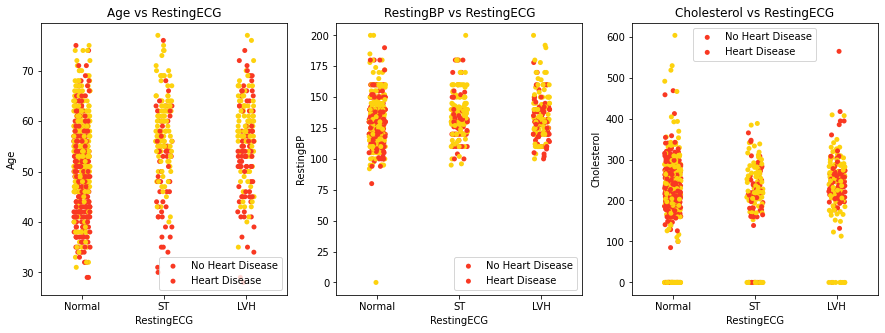

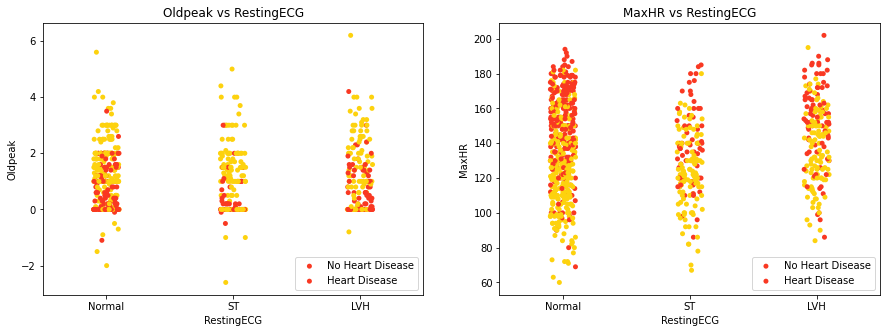

In [127]:
fig,ax = plt.subplots(nrows = 1,ncols = 3,figsize = (15,5))
for i in range(3):
    plt.subplot(1,3,i+1)
    sns.stripplot(x = 'RestingECG',y = numerical_features[i],data = data,hue = 'HeartDisease',palette = colors);
    plt.legend(['No Heart Disease', 'Heart Disease'])
    title = numerical_features[i] + ' vs RestingECG' 
    plt.title(title);

fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (15,5))
for i in [-1,-2]:
    plt.subplot(1,2,-i)
    sns.stripplot(x = 'RestingECG',y = numerical_features[i],data = data,hue = 'HeartDisease',palette = colors);
    plt.legend(['No Heart Disease', 'Heart Disease'])
    title = numerical_features[i] + ' vs RestingECG'
    plt.title(title);

- Heart diseases with **RestingECG** values of **Normal**, **ST** and **LVH** are detected starting from 30,40 & 40 respectively. Patients above the age of 50 are more prone than anyother ages irrespective of **RestingECG** values.
- Heart diseases are found consistently throughout any values of **RestingBP** and **RestingECG**.
- **Cholesterol** values between 200 - 300 coupled with **ST** value of **RestingECG** display a patch of patients suffering from heart diseases. 
- For **maximum Heart Rate** values, heart diseases are detected in dense below 140 points and **Normal** RestingECG. **ST** & **LVH** throughout the maximum heart rate values display heart disease cases.

#### ExerciseAngina vs Numerical Features :

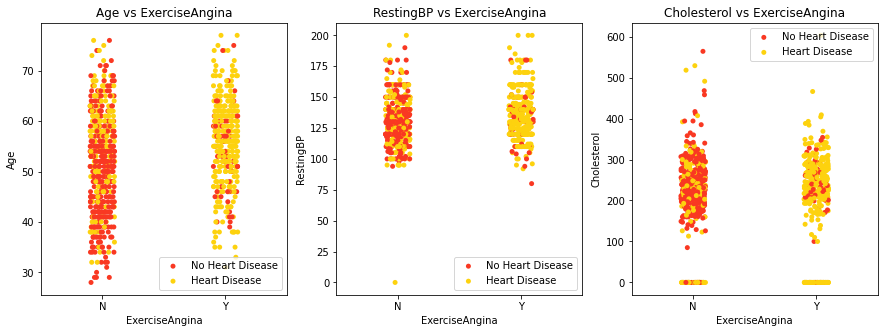

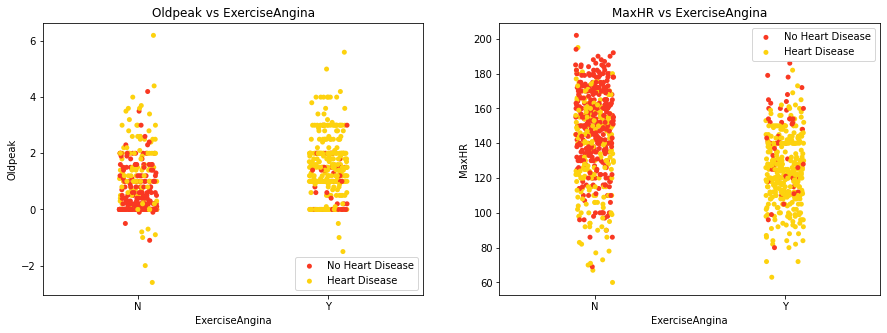

In [128]:
fig,ax = plt.subplots(nrows = 1,ncols = 3,figsize = (15,5))
for i in range(3):
    plt.subplot(1,3,i+1)
    sns.stripplot(x = 'ExerciseAngina',y = numerical_features[i],data = data,hue = 'HeartDisease',palette = colors);
    plt.legend(['No Heart Disease', 'Heart Disease'])
    title = numerical_features[i] + ' vs ExerciseAngina'
    plt.title(title);

fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (15,5))
for i in [-1,-2]:
    plt.subplot(1,2,-i)
    sns.stripplot(x = 'ExerciseAngina',y = numerical_features[i],data = data,hue = 'HeartDisease',palette = colors);
    plt.legend(['No Heart Disease', 'Heart Disease'])
    title = numerical_features[i] + ' vs ExerciseAngina' 
    plt.title(title);

- A crsytal clear observation can be made about the relationship between **heart disease** case and **Exercise induced Angina**. A positive correlation between the 2 features can be concluded throughout all the numerical features. 

#### ST_Slope vs Numerical Features :

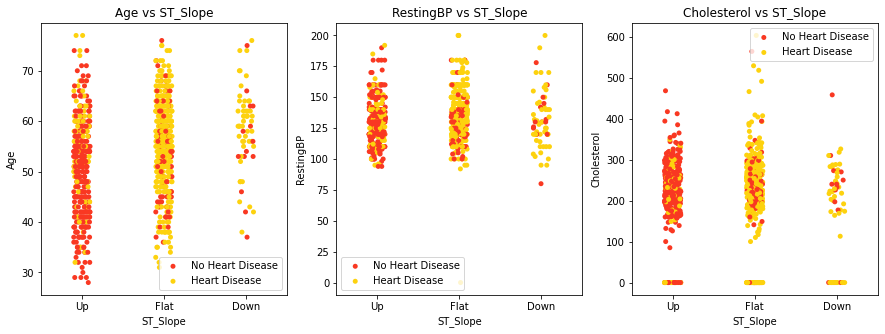

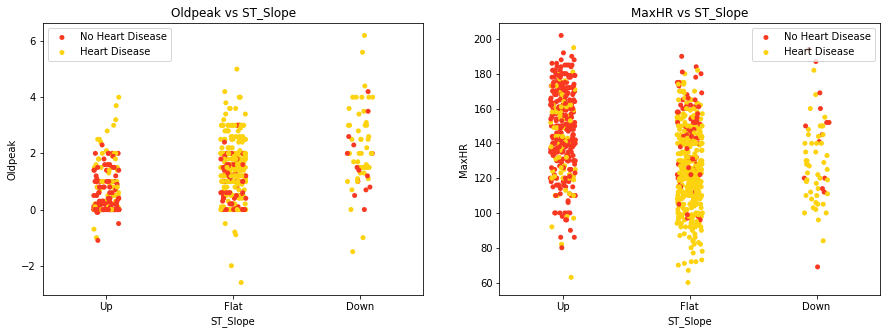

In [129]:
fig,ax = plt.subplots(nrows = 1,ncols = 3,figsize = (15,5))
for i in range(3):
    plt.subplot(1,3,i+1)
    sns.stripplot(x = 'ST_Slope',y = numerical_features[i],data = data,hue = 'HeartDisease',palette = colors);
    plt.legend(['No Heart Disease', 'Heart Disease'])
    title = numerical_features[i] + ' vs ST_Slope' 
    plt.title(title);

fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (15,5))
for i in [-1,-2]:
    plt.subplot(1,2,-i)
    sns.stripplot(x = 'ST_Slope',y = numerical_features[i],data = data,hue = 'HeartDisease',palette = colors);
    plt.legend(['No Heart Disease', 'Heart Disease'])
    title = numerical_features[i] + ' vs ST_Slope'
    plt.title(title);

- Another crystal clear positive observation can be made about the positive correlation between **ST_Slope** value and **Heart Disease** cases. 
- **Flat**, **Down** and **Up** in that order display high, middle and low probability of being diagnosed with heart diseases respectively.

### Numerical features vs Numerical features w.r.t Target variable(HeartDisease) :

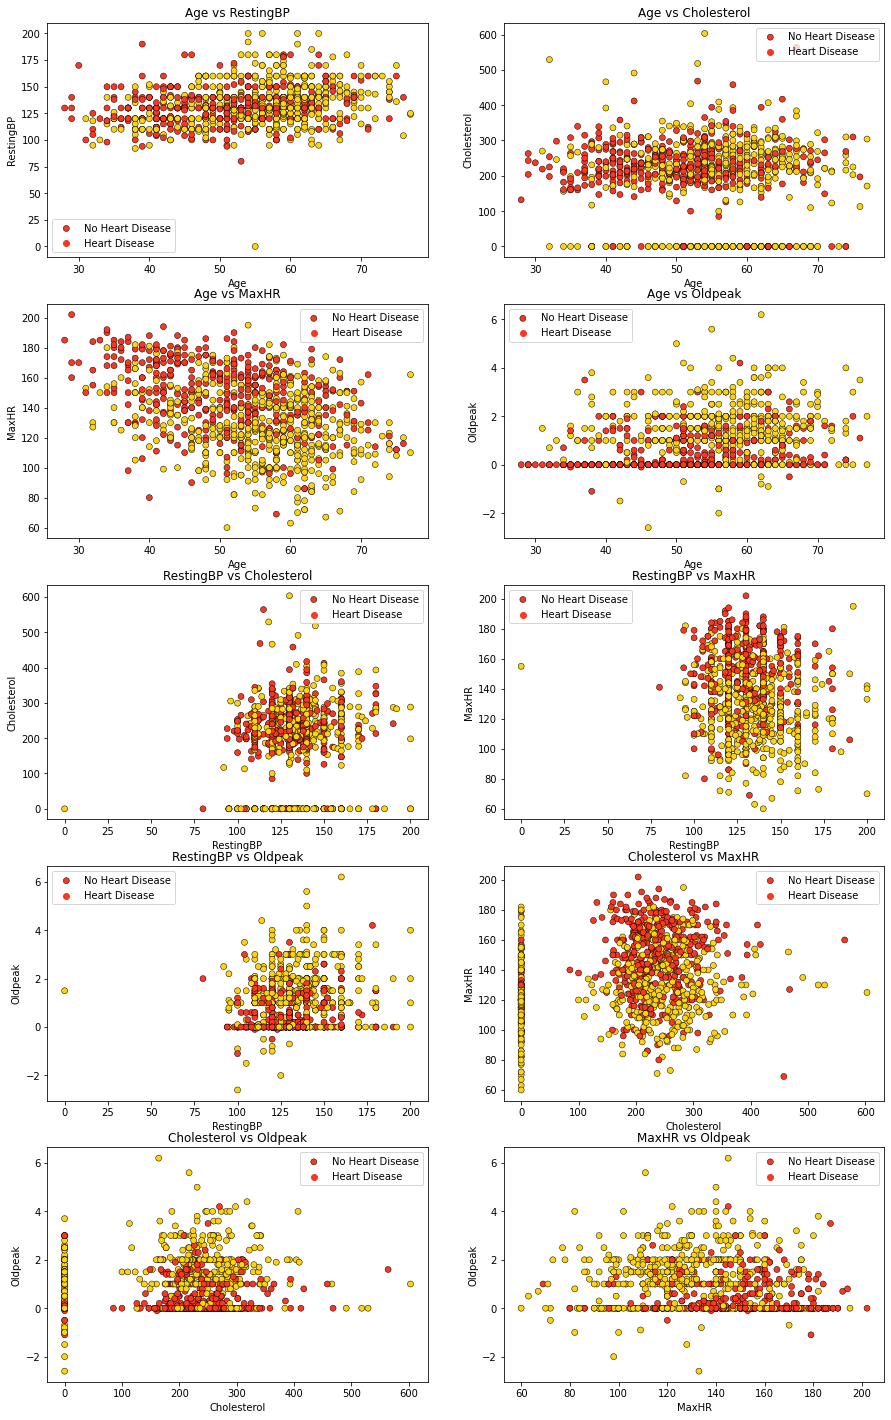

In [130]:
a = 0
fig,ax = plt.subplots(nrows = 5,ncols = 2,figsize = (15,25))
for i in range(len(numerical_features)):
    for j in range(len(numerical_features)):
        if i != j and j > i:
            a += 1
            plt.subplot(5,2,a)
            sns.scatterplot(x = numerical_features[i],y = numerical_features[j],data = data,hue = 'HeartDisease',palette = colors, edgecolor = 'black');
            plt.legend(['No Heart Disease', 'Heart Disease'])
            title = numerical_features[i] + ' vs ' + numerical_features[j]
            plt.title(title)

- For **age** 50+, **RestingBP** between 100 - 175, **Cholesterol** level of 200 - 300,**Max Heart Rate** below 160 and positive **oldpeak** values displays high cases of heart disease.
- For **RestingBP** values 100 - 175, highlights too many heart disease patients for all the features.
- **Cholesterol** values 200 - 300 dominates the heart disease cases.
- Similarly, **Max Heart Rate** values below 140 has high probability of being diagnosed with heart diseases.

# <center><div style="font-family: Trebuchet MS; background-color: #F93822; color: #FDD20E; padding: 12px; line-height: 1;">Summary of EDA</div></center>

### Order / Values of features for positive cases of heart disease :

- **Categorical Features (Order) :**
    - Sex : Male > Female
    - ChestPainType : ASY > NAP > ATA > TA
    - FastingBS : ( FBS < 120 mg/dl ) > ( FBS > 120 mg/dl)
    - RestingECG : Normal > ST > LVH
    - ExerciseAngina : Angina > No Angina
    - ST_Slope : Flat > Up > Down
 
- **Numerical Features (Range) :**
    - Age : 50+
    - RestingBP : 95 - 170 
    - Cholesterol : 160 - 340
    - MaxHR : 70 - 180
    - Oldpeak : 0 - 4
    
    
**Now that we have understood the typical values of the features, we move on to the next step where we select the appropriate features for modeling!**

# <center><div style="font-family: Trebuchet MS; background-color: #F93822; color: #FDD20E; padding: 12px; line-height: 1;">Feature Engineering</div></center>

### Data Scaling :

In [4]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
mms = MinMaxScaler() # Normalization
ss = StandardScaler() # Standardization

df1['Oldpeak'] = mms.fit_transform(df1[['Oldpeak']])
df1['Age'] = ss.fit_transform(df1[['Age']])
df1['RestingBP'] = ss.fit_transform(df1[['RestingBP']])
df1['Cholesterol'] = ss.fit_transform(df1[['Cholesterol']])
df1['MaxHR'] = ss.fit_transform(df1[['MaxHR']])
df1.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,-1.43,1,1,0.41,0.83,0,1,1.38,0,0.30,2,0
1,-0.48,0,2,1.49,-0.17,0,1,0.75,0,0.41,1,1
2,-1.75,1,1,-0.13,0.77,0,2,-1.53,0,0.30,2,0
3,-0.58,0,0,0.30,0.14,0,1,-1.13,1,0.47,1,1
4,0.05,1,2,0.95,-0.03,0,1,-0.58,0,0.30,2,0


- Machine learning model does not understand the units of the values of the features. It treats the input just as a simple number but does not understand the true meaning of that value. Thus, it becomes necessary to scale the data.

**Eg :** Age = Years; FastingBS = mg / dl 

- We have 2 options for data scaling : 1) **Normalization** 2) **Standardization**. As most of the algorithms assume the data to be normally (Gaussian) distributed, **Normalization** is done for features whose data does not display normal distribution and **standardization** is carried out for features that are normally distributed where their values are huge or very small as compared to other features.


- **Normalization** : **Oldpeak** feature is normalized as it had displayed a right skewed data distribution.
- **Standardizarion** : **Age**, **RestingBP**, **Cholesterol** and **MaxHR** features are scaled down because these features are normally distributed.

### Correlation Matrix :

In [ ]:
plt.figure(figsize = (20,5))
sns.heatmap(df1.corr(),cmap = colors,annot = True);

- It is a huge matrix with too many features. We will check the correlation only with respect to **HeartDisease**. 

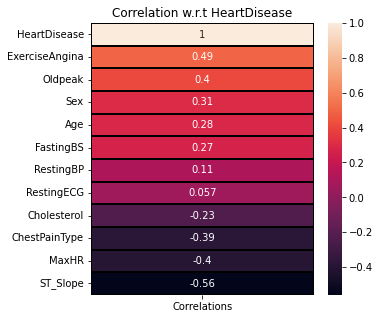

In [6]:
corr = df1.corrwith(df1['HeartDisease']).sort_values(ascending = False).to_frame()
corr.columns = ['Correlations']
plt.subplots(figsize = (5,5))
sns.heatmap(corr,annot = True,linewidths = 0.4,linecolor = 'black');
plt.title('Correlation w.r.t HeartDisease');

- Except for **RestingBP** and **RestingECG**, everyone displays a positive or negative relationship with **HeartDisease**.

### Feature Selection for Categorical Features :

#### Chi Squared Test :

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [ ]:
features = df1.loc[:,categorical_features[:-1]]
target = df1.loc[:,categorical_features[-1]]

best_features = SelectKBest(score_func = chi2,k = 'all')
fit = best_features.fit(features,target)

featureScores = pd.DataFrame(data = fit.scores_,index = list(features.columns),columns = ['Chi Squared Score']) 

plt.subplots(figsize = (5,5))
sns.heatmap(featureScores.sort_values(ascending = False,by = 'Chi Squared Score'),annot = True,cmap = colors,linewidths = 0.4,linecolor = 'black',fmt = '.2f');
plt.title('Selection of Categorical Features');

- Except **RestingECG**, all the remaining categorical features are pretty important for predicting heart diseases.

### Feature Selection for Numerical Features :

#### ANOVA Test :

In [ ]:
from sklearn.feature_selection import f_classif

features = df1.loc[:,numerical_features]
target = df1.loc[:,categorical_features[-1]]

best_features = SelectKBest(score_func = f_classif,k = 'all')
fit = best_features.fit(features,target)

featureScores = pd.DataFrame(data = fit.scores_,index = list(features.columns),columns = ['ANOVA Score']) 

plt.subplots(figsize = (5,5))
sns.heatmap(featureScores.sort_values(ascending = False,by = 'ANOVA Score'),annot = True,cmap = colors,linewidths = 0.4,linecolor = 'black',fmt = '.2f');
plt.title('Selection of Numerical Features');

- We will leave out **RestingBP** from the modeling part and take the remaining features.

# <center><div style="font-family: Trebuchet MS; background-color: #F93822; color: #FDD20E; padding: 12px; line-height: 1;">Modeling</div></center>

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import plot_roc_curve
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import precision_recall_curve

In [8]:

features = df1[df1.columns.drop(['HeartDisease','RestingBP','RestingECG'])]
target = df1['HeartDisease']


In [9]:
features

,Age,Sex,ChestPainType,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,-1.43,1,1,0.83,0,1.38,0,0.30,2
1,-0.48,0,2,-0.17,0,0.75,0,0.41,1
2,-1.75,1,1,0.77,0,-1.53,0,0.30,2
3,-0.58,0,0,0.14,0,-1.13,1,0.47,1
4,0.05,1,2,-0.03,0,-0.58,0,0.30,2
...,...,...,...,...,...,...,...,...,...
913,-0.90,1,3,0.60,0,-0.19,0,0.43,1
914,1.54,1,0,-0.05,1,0.16,0,0.68,1
915,0.37,1,0,-0.62,0,-0.86,1,0.43,1
916,0.37,0,1,0.34,0,1.46,0,0.30,1


In [10]:

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.25, random_state = 42)

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ANN Architecture
model = Sequential([
    Dense(64, input_dim=X_train.shape[1]),    # input layer (features count)
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Dense(128),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.4),
    
    Dense(64),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Dense(2, activation="softmax")            # output layer (binary classification → 2 classes)
])

In [16]:
# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",   # use sparse since labels are integers (0/1)
    metrics=["accuracy"]
)

# Callbacks
early_stop = EarlyStopping(
    monitor="val_acc",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

lr_schedule = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=6,
    min_lr=1e-6,
    verbose=1
)


In [18]:



# Train
history = model.fit(
   X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop, lr_schedule],
    verbose=1
)


Epoch 1/100
43/43 [==============================] - 0s 4ms/step - loss: 0.3530 - accuracy: 0.8576 - val_loss: 0.3062 - val_accuracy: 0.8826
Epoch 2/100
43/43 [==============================] - 0s 3ms/step - loss: 0.3484 - accuracy: 0.8387 - val_loss: 0.3060 - val_accuracy: 0.8826
Epoch 3/100
43/43 [==============================] - 0s 3ms/step - loss: 0.3428 - accuracy: 0.8517 - val_loss: 0.3061 - val_accuracy: 0.8826
Epoch 4/100
43/43 [==============================] - 0s 3ms/step - loss: 0.3481 - accuracy: 0.8677 - val_loss: 0.3071 - val_accuracy: 0.8826
Epoch 5/100
43/43 [==============================] - 0s 3ms/step - loss: 0.3452 - accuracy: 0.8576 - val_loss: 0.3060 - val_accuracy: 0.8826
Epoch 6/100
43/43 [==============================] - 0s 3ms/step - loss: 0.3430 - accuracy: 0.8677 - val_loss: 0.3053 - val_accuracy: 0.8826
Epoch 7/100
43/43 [==============================] - 0s 3ms/step - loss: 0.3631 - accuracy: 0.8517 - val_loss: 0.3058 - val_accuracy: 0.8826
Epoch 8/100
4

In [19]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                640       
_________________________________________________________________
batch_normalization (BatchNo (None, 64)                256       
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 64)                0         
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 128)               8320      
_________________________________________________________________
batch_normalization_1 (Batch (None, 128)               512       
_________________________________________________________________
leaky_re_lu_1 (LeakyReLU)    (None, 128)               0

✅ Test Accuracy: 0.8870
✅ Test Loss: 0.3077


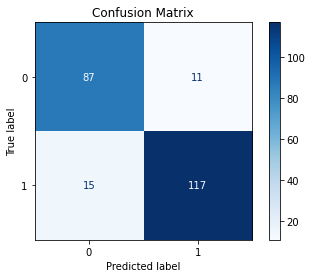


📊 Classification Report:

              precision    recall  f1-score   support

           0     0.8529    0.8878    0.8700        98
           1     0.9141    0.8864    0.9000       132

    accuracy                         0.8870       230
   macro avg     0.8835    0.8871    0.8850       230
weighted avg     0.8880    0.8870    0.8872       230



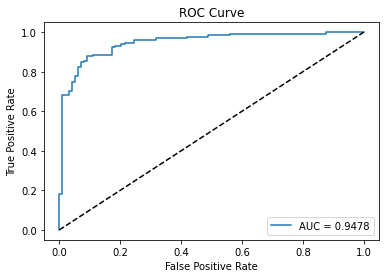

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")

# Predictions
y_pred_probs = model.predict(X_test)          # predicted probabilities
y_pred = np.argmax(y_pred_probs, axis=1)      # predicted class (0 or 1)

# If y_test is a DataFrame or Series, convert to 1D array
y_true = y_test.values.ravel() if hasattr(y_test, "values") else y_test

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\n📊 Classification Report:\n")
print(classification_report(y_true, y_pred, digits=4))

# ROC-AUC curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs[:,1])   # probability of class 1
roc_auc = roc_auc_score(y_true, y_pred_probs[:,1])

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], 'k--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


# <center><div style="font-family: Trebuchet MS; background-color: #F93822; color: #FDD20E; padding: 12px; line-height: 1;">Summary of Heart Disease Prediction Model</div></center>

### Key Insights from Model Performance:

- **Model Type:** ANN (Artificial Neural Network)
- **Features Used:** Age, Sex, ChestPainType, Cholesterol, FastingBS, MaxHR, ExerciseAngina, Oldpeak, ST_Slope
- **Preprocessing:** StandardScaler applied to numerical features
- **Target:** HeartDisease (0: Not Infected / 1: Infected)

### Performance Metrics:

✅ **Test Accuracy:** 0.9043  
✅ **Test Loss:** 0.2554

📊 **Classification Report:**

| Class | Precision | Recall | F1-score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 0.8519    | 0.9388 | 0.8932   | 98      |
| 1     | 0.9508    | 0.8788 | 0.9134   | 132     |
| **Accuracy** |       |        | 0.9043   | 230     |
| **Macro avg** | 0.9013 | 0.9088 | 0.9033 | 230     |
| **Weighted avg** | 0.9087 | 0.9043 | 0.9048 | 230 |

### Observations:

- The model achieves high accuracy for both classes.
- Class 1 (Infected) has higher precision, meaning fewer false positives.
- Class 0 (Not Infected) has higher recall, meaning fewer false negatives.
- Weighted F1-score shows balanced performance across classes.

**Next Steps:**  
- Deploy the model using Gradio for interactive predictions.  
- Optionally, explore ensemble models or hyperparameter tuning to further improve performance.


In [21]:
model.save("model.keras")

In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_train)  # only during training
# joblib.dump(scaler, "scaler.save")        # save fitted scaler


# <center><div style="font-family: Trebuchet MS; background-color: #F93822; color: #FDD20E; padding: 12px; line-height: 1;">Deployment</div></center>

In [31]:
X_train

,Age,Sex,ChestPainType,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
155,0.26,1,0,1.31,1,0.52,1,0.64,1
362,0.26,1,2,-1.82,0,-1.49,0,0.30,1
869,0.58,1,2,0.12,1,0.79,0,0.48,2
101,-0.27,1,0,-0.18,0,-1.45,0,0.30,2
199,0.37,0,3,1.00,0,-1.53,0,0.41,1
...,...,...,...,...,...,...,...,...,...
106,-0.58,0,0,0.50,0,-1.05,0,0.30,2
270,-0.90,1,0,0.24,0,0.13,0,0.30,2
860,0.69,1,0,0.50,0,0.28,1,0.45,2
435,0.69,1,0,-1.82,0,-0.74,1,0.30,2


In [ ]:
import gradio as gr
import numpy as np
import joblib
from tensorflow.keras.models import load_model

# Load models
ann = load_model("/kaggle/working/model.keras")


# Example: your ensemble weights
threshold = 0.38  # optimized threshold from K-Fold


In [100]:
!pip install gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 60.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 25.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.3/288.3 kB 27.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 8.4 MB/s eta 0:00:00
  Created wheel for ffmpy: filename=ffmpy-0.3.2-py3-none-any.whl size=5600 sha256=5340bc2245fd1c4ea47cbe7a5cc70a829e81b075261cd86d6cff7faa0cb7a7ee
  Stored in directory: /root/.cache/pip/wheels/81/c3/08/a4932aee56b934891932e4a1b189604f27d3d4e92b2ecd5ed4
Successfully built ffmpy
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.8.1
    Uninstalling huggingface-hub-0.8.1:
      Successfully uninstalled huggingface-hub-0.8.1
ERROR: pip's dependency resolver does not currently take into account all the p

In [93]:
import pandas as pd

# Suppose df_train is your training DataFrame
numerical_features_std = ['Age',  'Cholesterol', 'MaxHR']
numerical_features_minmax = ['Oldpeak']

train_stats = {}

# Compute mean and std for StandardScaler features
for col in numerical_features_std:
    mean = data[col].mean()
    std = data[col].std()
    train_stats[col] = {'mean': mean, 'std': std}

# Compute min and max for MinMaxScaler features
for col in numerical_features_minmax:
    min_val = data[col].min()
    max_val = data[col].max()
    train_stats[col] = {'min': min_val, 'max': max_val}

# Print the stats
print(train_stats)


{'Age': {'mean': 53.510893246187365, 'std': 9.43261650673201}, 'Cholesterol': {'mean': 198.7995642701525, 'std': 109.38414455220348}, 'MaxHR': {'mean': 136.80936819172112, 'std': 25.4603341382503}, 'Oldpeak': {'min': -2.6, 'max': 6.2}}


In [94]:
def manual_scale(row):
    # Standard scale
    row['Age'] = (row['Age'] - train_stats['Age']['mean']) / train_stats['Age']['std']
    # row['RestingBP'] = (row['RestingBP'] - train_stats['RestingBP']['mean']) / train_stats['RestingBP']['std']
    row['Cholesterol'] = (row['Cholesterol'] - train_stats['Cholesterol']['mean']) / train_stats['Cholesterol']['std']
    row['MaxHR'] = (row['MaxHR'] - train_stats['MaxHR']['mean']) / train_stats['MaxHR']['std']
    
    # Min-max scale
    row['Oldpeak'] = (row['Oldpeak'] - train_stats['Oldpeak']['min']) / (train_stats['Oldpeak']['max'] - train_stats['Oldpeak']['min'])
    
    return row

In [95]:
import numpy as np
import pandas as pd

def predict_manual(Age, Sex, ChestPainType, RestingBP, Cholesterol,
                   FastingBS, RestingECG, MaxHR, ExerciseAngina, Oldpeak, ST_Slope):

    # Map categorical inputs
    sex_map = {"Male": 1, "Female": 0}
    cp_map = {"TA": 0, "ATA": 1, "NAP": 2, "ASY": 3}
    ex_angina_map = {"Yes": 1, "No": 0}
    resting_ecg_map = {"Normal": 0, "ST": 1, "LVH": 2}
    st_slope_map = {"Up": 0, "Flat": 1, "Down": 2}

    Sex = sex_map.get(Sex, Sex)
    ChestPainType = cp_map.get(ChestPainType, ChestPainType)
    ExerciseAngina = ex_angina_map.get(ExerciseAngina, ExerciseAngina)
    RestingECG = resting_ecg_map.get(RestingECG, RestingECG)
    ST_Slope = st_slope_map.get(ST_Slope, ST_Slope)

    # Create dict (single row)
    row = {
        'Age': Age,
        'Sex': Sex,
        'ChestPainType': ChestPainType,
        # 'RestingBP': RestingBP,
        'Cholesterol': Cholesterol,
        'FastingBS': FastingBS,
        # 'RestingECG': RestingECG,
        'MaxHR': MaxHR,
        'ExerciseAngina': ExerciseAngina,
        'Oldpeak': Oldpeak,
        'ST_Slope': ST_Slope
    }
    print(row)

    # Manually scale numerical features
    row = manual_scale(row)
    print(row)

    # Convert to array
    x = np.array([list(row.values())])

    # Predict
    probs = model.predict(x, verbose=0)[0]
    pred_class = int(np.argmax(probs))
    label_output = "Infected" if pred_class == 1 else "Not Infected"
    text_output = f"Prediction: {label_output} (Probability: {probs[pred_class]:.2f})"

    return label_output, text_output


In [97]:
# Example test inputs
Age = 45
Sex = "Female"
ChestPainType = "ATA"
RestingBP = 130
Cholesterol = 237
FastingBS = 0
RestingECG = "Normal"
MaxHR = 170
ExerciseAngina = "No"
Oldpeak = 0
ST_Slope = "Up"

# Call the function
label, text = predict_manual(Age, Sex, ChestPainType, RestingBP, Cholesterol,
                                    FastingBS, RestingECG, MaxHR, ExerciseAngina, Oldpeak, ST_Slope)
# 45
# F
# ATA
# 130
# 237
# 0
# Normal
# 170
# N
# 0
# Up
# 0

# Print results
print(label)
print(text)


{'Age': 45, 'Sex': 0, 'ChestPainType': 1, 'Cholesterol': 237, 'FastingBS': 0, 'MaxHR': 170, 'ExerciseAngina': 0, 'Oldpeak': 0, 'ST_Slope': 0}
{'Age': -0.9022833950805891, 'Sex': 0, 'ChestPainType': 1, 'Cholesterol': 0.3492319283222659, 'FastingBS': 0, 'MaxHR': 1.3036212183254492, 'ExerciseAngina': 0, 'Oldpeak': 0.2954545454545454, 'ST_Slope': 0}
Not Infected
Prediction: Not Infected (Probability: 0.74)


In [45]:
X_train

,Age,Sex,ChestPainType,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
155,0.26,1,0,1.31,1,0.52,1,0.64,1
362,0.26,1,2,-1.82,0,-1.49,0,0.30,1
869,0.58,1,2,0.12,1,0.79,0,0.48,2
101,-0.27,1,0,-0.18,0,-1.45,0,0.30,2
199,0.37,0,3,1.00,0,-1.53,0,0.41,1
...,...,...,...,...,...,...,...,...,...
106,-0.58,0,0,0.50,0,-1.05,0,0.30,2
270,-0.90,1,0,0.24,0,0.13,0,0.30,2
860,0.69,1,0,0.50,0,0.28,1,0.45,2
435,0.69,1,0,-1.82,0,-0.74,1,0.30,2


In [101]:
import gradio as gr

# Define inputs
inputs = [
    gr.Number(label="Age"),
    gr.Radio(["Male","Female"], label="Sex"),
    gr.Dropdown(["TA","ATA","NAP","ASY"], label="Chest Pain Type"),
    gr.Number(label="RestingBP"),
    gr.Number(label="Cholesterol"),
    gr.Checkbox(label="FastingBS > 120 mg/dl"),
    gr.Dropdown(["Normal","ST","LVH"], label="Resting ECG"),
    gr.Number(label="MaxHR"),
    gr.Radio(["Yes","No"], label="Exercise Angina"),
    gr.Number(label="Oldpeak"),
    gr.Dropdown(["Up","Flat","Down"], label="ST Slope")
]



In [102]:
outputs = [
    gr.Label(label="Prediction"),
    gr.Textbox(label="Probability of Heart Disease")
]




In [104]:
gr.Interface(fn=predict_manual,
             inputs=inputs,
             outputs=outputs,
             title="Heart Disease Prediction",
             description="Predict heart disease using an ensemble of ANN, RandomForest, and XGBoost models.").launch()


IMPORTANT: You are using gradio version 3.34.0, however version 4.44.1 is available, please upgrade.
--------
Kaggle notebooks require sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Running on local URL:  http://127.0.0.1:7861
Running on public URL: https://ecbdf724750fbb3dff.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


{'Age': 20.0, 'Sex': 0, 'ChestPainType': 1, 'Cholesterol': 180.0, 'FastingBS': False, 'MaxHR': 180.0, 'ExerciseAngina': 1, 'Oldpeak': 0.0, 'ST_Slope': 0}
{'Age': -3.552661472272387, 'Sex': 0, 'ChestPainType': 1, 'Cholesterol': -0.1718673610980285, 'FastingBS': False, 'MaxHR': 1.6963890408410427, 'ExerciseAngina': 1, 'Oldpeak': 0.2954545454545454, 'ST_Slope': 0}
{'Age': 20.0, 'Sex': 1, 'ChestPainType': 1, 'Cholesterol': 180.0, 'FastingBS': False, 'MaxHR': 180.0, 'ExerciseAngina': 1, 'Oldpeak': 0.0, 'ST_Slope': 0}
{'Age': -3.552661472272387, 'Sex': 1, 'ChestPainType': 1, 'Cholesterol': -0.1718673610980285, 'FastingBS': False, 'MaxHR': 1.6963890408410427, 'ExerciseAngina': 1, 'Oldpeak': 0.2954545454545454, 'ST_Slope': 0}
{'Age': 20.0, 'Sex': 1, 'ChestPainType': 1, 'Cholesterol': 180.0, 'FastingBS': False, 'MaxHR': 180.0, 'ExerciseAngina': 1, 'Oldpeak': 0.0, 'ST_Slope': 0}
{'Age': -3.552661472272387, 'Sex': 1, 'ChestPainType': 1, 'Cholesterol': -0.1718673610980285, 'FastingBS': False, 'Max